# Support Vector Machine

Aim to identify a hyperplane (n-1 dimensional) to separate the data points into distinguishable classes.

The major concept used here is the maximal margin classifier: we choose the hyperplane that maximizes the distance (margin) between the nearest points of each class and the decision boundary. 
The observations that lie exactly on the margin boundaries are called support vectors; these points alone determine the position and orientation of the separating hyperplane.

![alt text](sphx_glr_plot_svm_margin_thumb.webp)

Lastly SVM is aka Soft Margin Classiifier meaining it allows some misclassification within margins classes from hyperplane.



The soft margin is controlled by the regularization parameter `C`, which balances a wider margin against allowing classification errors.

For a linear SVM the decision boundary is given by: $$w\cdot x + b = 0$$

The support vectors lie on the linear margin planes with equations: $$w\cdot x + b = 1$$ and $$w\cdot x + b = -1$$

In [29]:

from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


X_arr, y_arr = make_classification(
    n_samples=500,
    n_features=3,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.2, 0.3],
    class_sep=1.7,
    random_state=0
)

df = pd.DataFrame(X_arr, columns=['f1','f2','f3'])
df['y'] = y_arr

In [30]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(train_df[['f1', 'f2', 'f3']], train_df['y'])
preds=svm_model.predict(test_df[['f1', 'f2', 'f3']])
print("Accuracy:", accuracy_score(test_df['y'], preds))
print("Confusion Matrix:\n", confusion_matrix(test_df['y'], preds))
print("Classification Report:\n", classification_report(test_df['y'], preds))

Accuracy: 0.95
Confusion Matrix:
 [[42  3]
 [ 2 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        45
           1       0.95      0.96      0.95        55

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



## The kernel trick
When we encounter data which the model is unable to fit a linear hyperplane to separate it , we can transform / map the data to a higher dimensional space and fit a hyperplane to the transformed data.

The mapping to higher dimensions is done by a kernel function.
#### Polynomial 
- map data to n-D space and compares relation between data points inn that space
    
    $K(x_i,x_j)= (x_i*x_j+b)^d$

$x_i ,x_j$ - data points to compared

$b$ - kernel coefficient

$d$ - polynomial degree to transform to

#### RBF(Radial Basis)

$K(x_i,x_j)=e^{-\gamma(x_i-x_j)^2}$

This tries to map distance between two data observations as a the relationship between the two points. Basically similar to working of a KNN classifier.



In [31]:

from sklearn.preprocessing import PolynomialFeatures



X = X_arr
y = y_arr


poly = PolynomialFeatures(degree=2, include_bias=False)
X_nl = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_nl, y, test_size=0.3, random_state=0, stratify=y
)


clf = SVC(kernel='poly', gamma='scale', C=1.0, random_state=0)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9266666666666666
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        67
           1       0.94      0.93      0.93        83

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



In [32]:
from sklearn.datasets import make_circles


X, y = make_circles(n_samples=500, factor=0.16, noise=0.3, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

clf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=0)
clf.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

Accuracy: 0.9


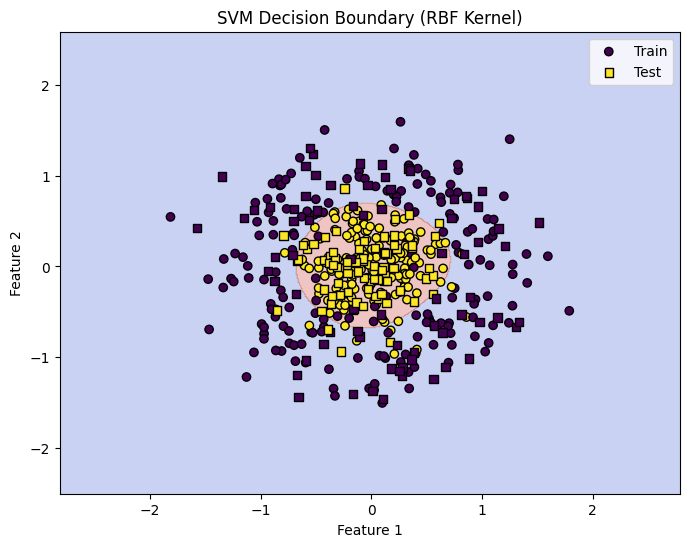

In [33]:


# Create a meshgrid for plotting decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict on the meshgrid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='s', edgecolors='k', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary (RBF Kernel)')
plt.legend()
plt.show()

# The Regressor using SVM
We can repurpose the SVM to become a regression model by reversing its objective. Instead of trying to find the largest possible margin between two classes while limiting margin violations (as done in classification), Support Vector Regression (SVR) tries to fit as many training instances as possible within the margin while limiting margin violations (instances outside the margin). these points points outside this margin are taken as the Support vectors here and the model plans to minimise that 

The width of this margin is controlled by a hyperparameter, $\epsilon$ (epsilon). Because adding more training instances within the margin does not affect the model's predictions, the model is often described as being $\epsilon$-insensitive. Just like with SVM classification, we can use kernel tricks (such as Polynomial or RBF kernels) to effectively handle non-linear regression tasks.


In [37]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = load_diabetes()
X = data.data
y = data.target

X_scaler = StandardScaler()
y_scaler = StandardScaler()


X_tr = X_scaler.fit_transform(X_train)
X_te = X_scaler.transform(X_test) 
y_tr = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_te = y_scaler.transform(y_test.reshape(-1, 1)).ravel()  
svr= SVR(kernel='linear', C=107.0, gamma=0.5, epsilon=0.1)

svr.fit(X_tr, y_tr)

y_pred = svr.predict(X_te)

mse = mean_squared_error(y_te,y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te, y_pred)
r2 = r2_score(y_te, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"Root Mean Squared (RMSE):  {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2):            {r2:.2f}")



--- Model Evaluation ---
Mean Squared Error (MSE):  0.49
Root Mean Squared (RMSE):  0.70
Mean Absolute Error (MAE): 0.55
R-squared (R2):            0.44


## Optimiser

### SVM 



In SVM classification, we want to maximize the margin between classes while allowing some misclassifications  

So instead of perfectly fitting every point, we allow some errors but try to keep the boundary as robust and generalizable as possible



### Mathematical objective

$$
\min_{w,b} \ \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} \xi_i
$$



### Constraints

$$
y_i (w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$



### What each term means (deep intuition)

- $\frac{1}{2} \|w\|^2$  
  This term tries to minimize the magnitude of weights
  inorder to get a flatter decision boundary giving us a larger margin


- $\xi_i$ (slack variables)  
   These measure how much each data point violates the margin

  Cases:
  - $\xi_i = 0$ → correctly classified and outside margin  
  - $0 < \xi_i < 1$ → inside margin but still correct  
  - $\xi_i > 1$ → misclassified  


- $C$ (regularization parameter)  
   Controls the trade-off:

  - large $C$ → strict → penalizes errors heavily → tries to fit training data closely  
  - small $C$ → relaxed → allows more violations → smoother boundary  

### SVR 



In SVR, instead of separating classes, we want to:

- fit a function that stays close to the data  
- ignore small errors  
- penalize only significant deviations



#### Mathematical objective

$$
\min_{w,b} \ \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} (\xi_i + \xi_i^*)
$$


#### Constraints

$$
y_i - (w^T x_i + b) \le \epsilon + \xi_i
$$

$$
(w^T x_i + b) - y_i \le \epsilon + \xi_i^*
$$

$$
\xi_i, \xi_i^* \ge 0
$$



- $\frac{1}{2} \|w\|^2$  keeps the function flat (smooth) avoids fiting of overly complex curves  



- $\epsilon$ (epsilon-insensitive zone) defines a tube around the predicted function

  - if prediction error is within $\epsilon$ → no penalty  
  - if outside → penalty starts  



- $\xi_i, \xi_i^*$ (slack variables) measure how far points lie outside the tube

  - $\xi_i$ → error above the tube  
  - $\xi_i^*$ → error below the tube  



- $C$ controls how much we care about points outside the tube  
  - large $C$ → strict → tries to fit data closely  
  - small $C$ → relaxed → smoother function  




### Loss 

This leads to:

$$ L = \max(0, |y - f(x)| - \epsilon) $$



- if $|y - f(x)| \le \epsilon$ → no loss (ignored)  
- if $|y - f(x)| > \epsilon$ → loss increases linearly  



